# 02 — Titanic predictive modelling pipeline

**Module:** `/analytics` · **Notebook 2 of 2** · continues directly from `01_eda.ipynb`

This notebook does **not** call `sns.load_dataset` again. It reads the `titanic.csv` that `01_eda.ipynb` saved right
after the one and only raw load, and applies the same row-level cleaning (`titanic_utils.drop_sparse_rows`).
Every learned preprocessing step (imputer, encoder, scaler) lives inside a scikit-learn `Pipeline`/`ColumnTransformer`,
so it is structurally impossible to fit it on anything other than the training split.

In [1]:
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve,
                             confusion_matrix, ConfusionMatrixDisplay, mean_absolute_error, mean_squared_error, r2_score)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

from titanic_utils import RAW_CSV, COLOR_SURVIVED, COLOR_DIED, COLOR_THIRD, drop_sparse_rows

SEED = 42
FIG = Path("figures"); FIG.mkdir(exist_ok=True)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 110})
pd.set_option("display.width", 140)

## Continue from the same data

In [2]:
df = drop_sparse_rows(pd.read_csv(RAW_CSV))      # same file + same row rule as 01_eda.ipynb
print("rows:", len(df))

NUMERIC = ["pclass", "age", "sibsp", "parch", "fare"]
CATEGORICAL = ["sex", "embarked"]
FEATURES = NUMERIC + CATEGORICAL
TARGET = "survived"

X, y = df[FEATURES], df[TARGET]
print("missing values in the chosen features (still raw — imputation happens inside the pipeline):")
print(X.isna().sum()[lambda s: s > 0])

rows: 889
missing values in the chosen features (still raw — imputation happens inside the pipeline):
age    177
dtype: int64


**Features used:** `pclass, age, sibsp, parch, fare` (numeric) and `sex, embarked` (categorical). The Part A story showed these carry the survival signal. Deliberately **excluded**:
- `alive`: it is the target spelled out as yes/no, so including it would be direct target leakage.
- `who`, `adult_male`, `class`, `embark_town`, `alone`: exact re-encodings of `sex`/`age`, `pclass`, `embarked`, and `sibsp + parch`.
- `deck`: 77% missing. EDA showed its "Missing" level mostly duplicates `pclass` (97.6% of 3rd class has no deck).

**Missing-value choice for modelling.** The only feature still missing here is `age` (177 NaN, 19.87%). Inside the pipeline I impute it with the **training-split median**, a plain median rather than the EDA's (sex, pclass) group median. It is simpler to express as a leak-free `SimpleImputer`, and the scaled `pclass`/`sex` features already sit next to it in every model. `embarked` gets a most-frequent imputer as a safety net for new raw data, even though its two NaN rows were already dropped by the <5% rule.

## Task 7 — Stratified train/test split (before any preprocessing)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=SEED)

split_balance = pd.DataFrame({
    "full data": y.value_counts(normalize=True),
    "train": y_train.value_counts(normalize=True),
    "test": y_test.value_counts(normalize=True),
}).mul(100).round(2).rename(index={0: "died %", 1: "survived %"})
print(f"train = {len(X_train)} rows, test = {len(X_test)} rows")
split_balance

train = 711 rows, test = 178 rows


,full data,train,test
survived,,,
died %,61.75,61.74,61.8
survived %,38.25,38.26,38.2


**Why stratify?** Task 1 measured a **61.62% / 38.38%** died/survived split, a 1.6 : 1 imbalance. With only 178 test rows, a plain random split could easily give a test set with, say, 34% or 43% survivors. Accuracy, precision and recall would then shift for reasons that have nothing to do with the model, and the train and test sets would describe different populations. `stratify=y` keeps the class ratio fixed in both parts: **38.26% survivors in train and 38.20% in test**, against 38.25% overall. The split happens **before** any imputer, encoder or scaler is fitted.

## Task 8 — Preprocessing: a `ColumnTransformer`, fitted on the training split only

In [4]:
def make_preprocessor():
    numeric = Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())])
    categorical = Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                            ("onehot", OneHotEncoder(handle_unknown="ignore", drop="if_binary"))])
    return ColumnTransformer([("num", numeric, NUMERIC), ("cat", categorical, CATEGORICAL)])

def make_pipeline(estimator):
    return Pipeline([("prep", make_preprocessor()), ("clf", estimator)])

# Demonstrate the fit-on-train / transform-on-test contract explicitly:
prep_demo = make_preprocessor().fit(X_train)                 # learns medians/categories/means from TRAIN only
Xt_train, Xt_test = prep_demo.transform(X_train), prep_demo.transform(X_test)   # test is transform-only
FEATURE_NAMES = [n.split("__")[1] for n in prep_demo.get_feature_names_out()]
print("encoded features:", FEATURE_NAMES)
print("age median learned from train:", prep_demo.named_transformers_["num"]["impute"].statistics_[1])
print("train means after scaling ~0:", Xt_train[:, :5].mean(axis=0).round(3))
print("test means after scaling (not exactly 0 — scaler never saw test):", Xt_test[:, :5].mean(axis=0).round(3))

encoded features: ['pclass', 'age', 'sibsp', 'parch', 'fare', 'sex_male', 'embarked_C', 'embarked_Q', 'embarked_S']
age median learned from train: 28.0
train means after scaling ~0: [-0. -0. -0.  0.  0.]
test means after scaling (not exactly 0 — scaler never saw test): [-0.072 -0.034  0.117 -0.009  0.024]


**Leakage check.** The imputer learned the age median (**28.0**) from the 711 training rows only. The scaled training features have mean exactly 0, while the test features do **not** (e.g. −0.072, +0.117). That is what we want to see: the scaler never looked at the test set, so the test set is only transformed. In the rest of the notebook each model is wrapped as `Pipeline([("prep", ColumnTransformer), ("clf", estimator)])`. Calling `.fit(X_train, y_train)` fits the preprocessor on train only, and `.predict(X_test)` applies it in transform-only mode, so the contract is enforced by structure, not by memory.

## Task 9 — Train three classifiers on the identical split

In [5]:
models = {
    "Logistic Regression": make_pipeline(LogisticRegression(max_iter=1000, random_state=SEED)),
    "Decision Tree": make_pipeline(DecisionTreeClassifier(max_depth=4, min_samples_leaf=5, random_state=SEED)),
    "Random Forest": make_pipeline(RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1)),
}
for name, pipe in models.items():
    pipe.fit(X_train, y_train)                    # each Pipeline fits its own preprocessor on X_train only
    print(f"{name:20s} train acc = {pipe.score(X_train, y_train):.3f} | test acc = {pipe.score(X_test, y_test):.3f}")

Logistic Regression  train acc = 0.797 | test acc = 0.815
Decision Tree        train acc = 0.824 | test acc = 0.798


Random Forest        train acc = 0.985 | test acc = 0.815


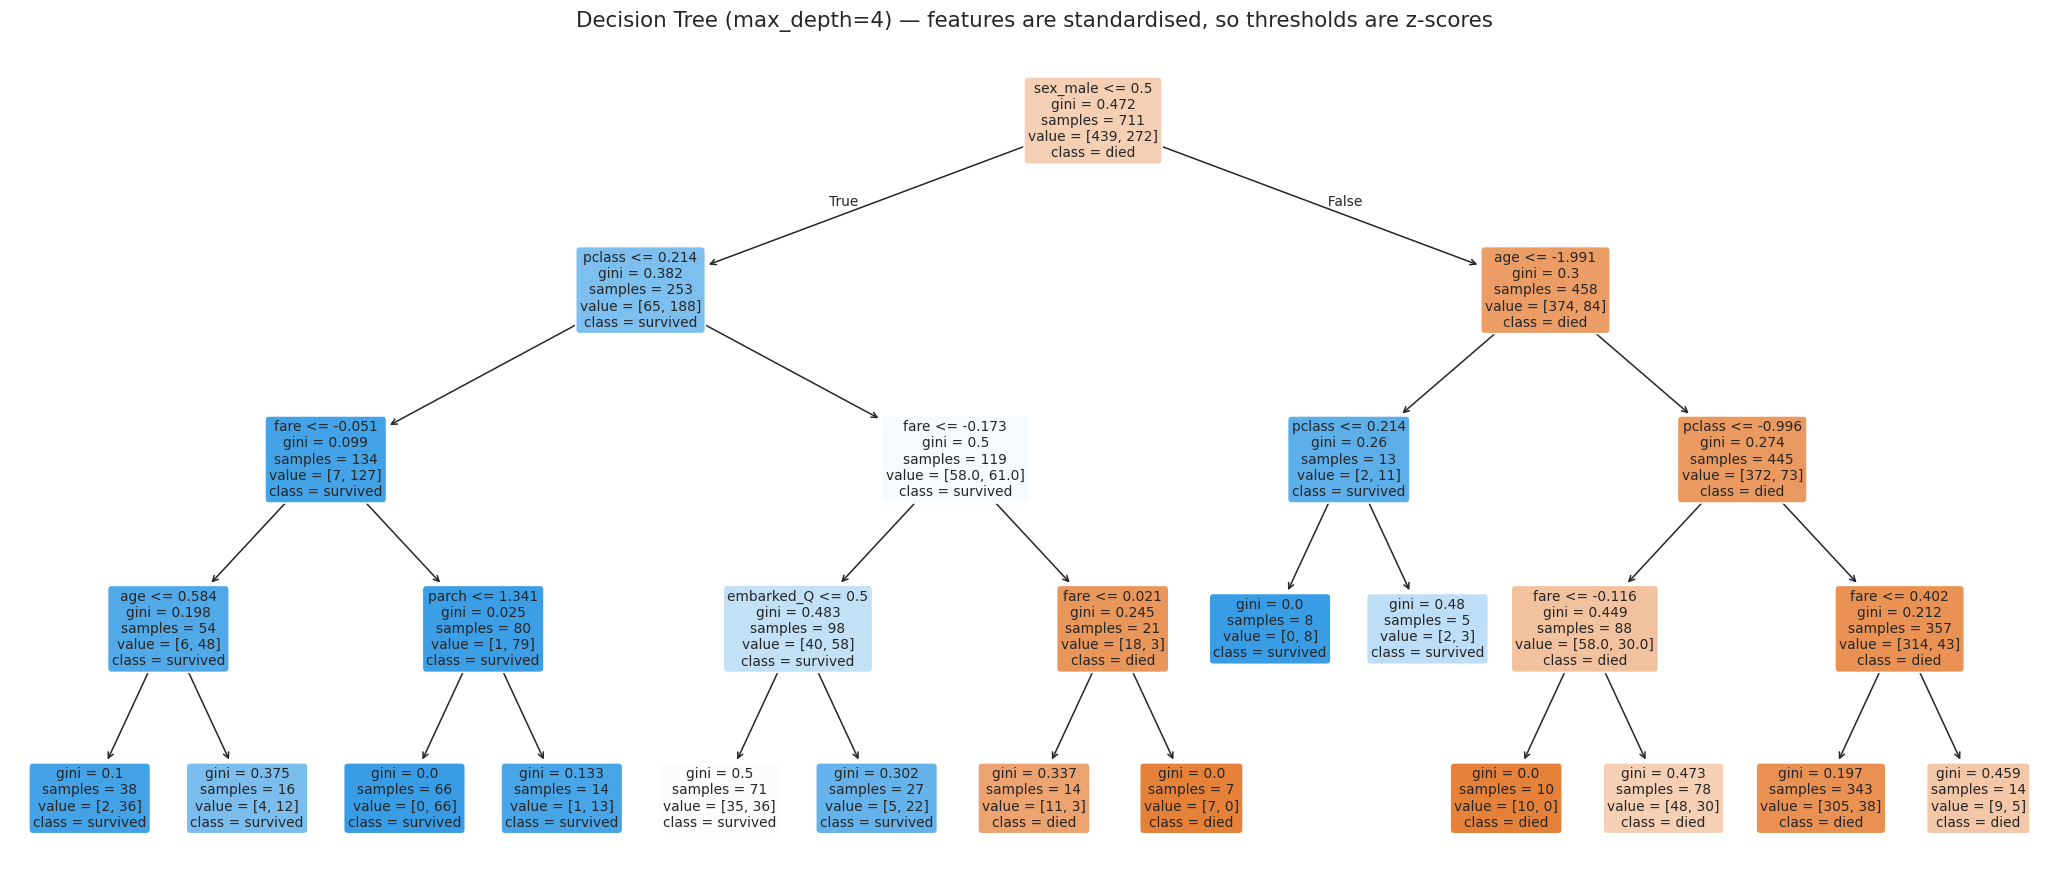

In [6]:
tree = models["Decision Tree"].named_steps["clf"]
fig, ax = plt.subplots(figsize=(24, 10))
plot_tree(tree, feature_names=FEATURE_NAMES, class_names=["died", "survived"], filled=True, rounded=True,
          impurity=True, proportion=False, fontsize=9, ax=ax)
ax.set_title("Decision Tree (max_depth=4) — features are standardised, so thresholds are z-scores", fontsize=14)
fig.savefig(FIG / "09_decision_tree.png", bbox_inches="tight"); plt.show()

**Reading the tree.** The root split is `sex_male <= 0.5`, i.e. **sex is the most informative single feature**, exactly as the EDA predicted. Women (left branch, 188 of 253 survived) are split next on `pclass`: 1st/2nd-class women are almost all "survived" (127/134), while for 3rd-class women the tree falls back on `fare` and `embarked`. Men (right, only 84/458 survived) are split first on **age** (`age <= −1.99` in z-units, age ≤ about 3.5 years: little boys, 11 of 13 survived), then by class and fare. The tree is capped at `max_depth=4` with `min_samples_leaf=5` so it stays readable and does not memorise the training set. Thresholds are shown in standardised units because the tree sits after the `StandardScaler`.

## Task 10 — Evaluate: confusion matrix, accuracy, precision, recall, F1, ROC/AUC

In [7]:
def evaluate(pipe, X_, y_):
    pred, proba = pipe.predict(X_), pipe.predict_proba(X_)[:, 1]
    return {"accuracy": accuracy_score(y_, pred), "precision": precision_score(y_, pred),
            "recall": recall_score(y_, pred), "f1": f1_score(y_, pred), "roc_auc": roc_auc_score(y_, proba)}

results = pd.DataFrame({name: evaluate(p, X_test, y_test) for name, p in models.items()}).T.round(4)
results

,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.8146,0.7966,0.6912,0.7402,0.8610
Decision Tree,0.7978,0.7759,0.6618,0.7143,0.8510
Random Forest,0.8146,0.7778,0.7206,0.7481,0.8283


Logistic Regression  TN=98 FP=12 FN=21 TP=47
Decision Tree        TN=97 FP=13 FN=23 TP=45
Random Forest        TN=96 FP=14 FN=19 TP=49


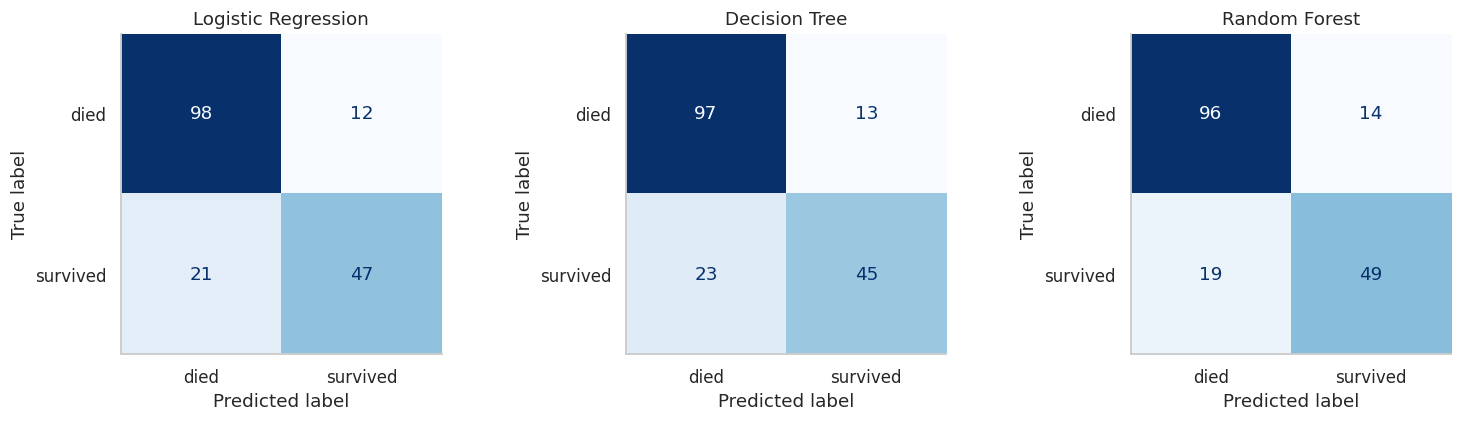

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, pipe) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, pipe.predict(X_test))
    ConfusionMatrixDisplay(cm, display_labels=["died", "survived"]).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name); ax.grid(False)
    tn, fp, fn, tp = cm.ravel(); print(f"{name:20s} TN={tn} FP={fp} FN={fn} TP={tp}")
fig.tight_layout(); fig.savefig(FIG / "10_confusion_matrices.png", bbox_inches="tight"); plt.show()

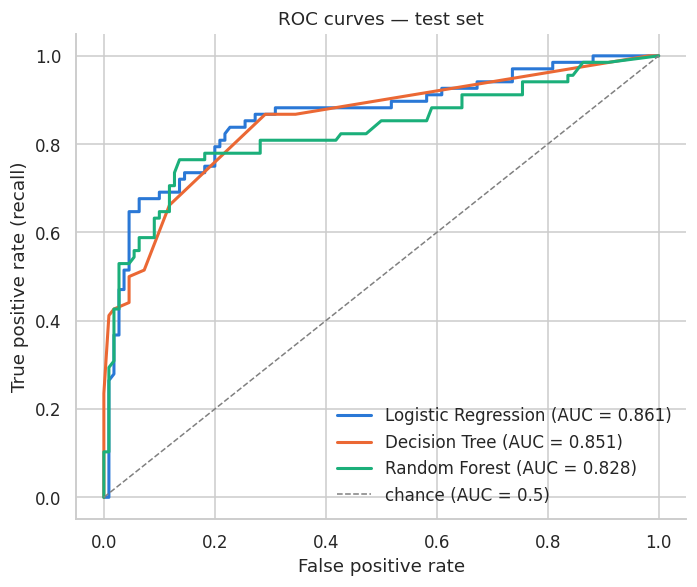

In [9]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
for (name, pipe), color in zip(models.items(), [COLOR_SURVIVED, COLOR_DIED, COLOR_THIRD]):
    fpr, tpr, _ = roc_curve(y_test, pipe.predict_proba(X_test)[:, 1])
    ax.plot(fpr, tpr, lw=2, color=color, label=f"{name} (AUC = {results.loc[name, 'roc_auc']:.3f})")
ax.plot([0, 1], [0, 1], ls="--", color="grey", lw=1, label="chance (AUC = 0.5)")
ax.set(xlabel="False positive rate", ylabel="True positive rate (recall)", title="ROC curves — test set")
ax.legend(loc="lower right", frameon=False)
fig.tight_layout(); fig.savefig(FIG / "11_roc_curves.png", bbox_inches="tight"); plt.show()

**Test-set results (178 passengers, 68 survivors):**

| Model | Accuracy | Precision | Recall | F1 | ROC-AUC | TN / FP / FN / TP |
|---|---|---|---|---|---|---|
| Logistic Regression | 0.8146 | 0.7966 | 0.6912 | 0.7402 | **0.8610** | 98 / 12 / 21 / 47 |
| Decision Tree (depth 4) | 0.7978 | 0.7759 | 0.6618 | 0.7143 | 0.8510 | 97 / 13 / 23 / 45 |
| Random Forest (default) | 0.8146 | 0.7778 | **0.7206** | **0.7481** | 0.8283 | 96 / 14 / 19 / 49 |

All three models are much better than the 61.8% "everyone died" baseline. **Logistic Regression ranks passengers best** (highest AUC 0.861). **The untuned Random Forest finds the most survivors** (recall 0.721, 49 true positives) at a small cost in precision. Its training accuracy of 0.985 against 0.815 on test shows it overfits when depth is unlimited, which explains its lowest AUC (0.828) and is why it gets tuned in Task 12. The depth-4 Decision Tree is the weakest on every metric. It trades accuracy for interpretability.

## Task 11 — Imbalance handling: baseline vs `class_weight='balanced'` vs SMOTE (Logistic Regression)

In [10]:
print("training-set class balance:", y_train.value_counts().to_dict(),
      f"-> minority share {y_train.mean():.2%}, ratio {(1 - y_train.mean()) / y_train.mean():.2f}:1")

variants = {
    "(a) baseline": make_pipeline(LogisticRegression(max_iter=1000, random_state=SEED)),
    "(b) class_weight='balanced'": make_pipeline(LogisticRegression(max_iter=1000, class_weight="balanced",
                                                                    random_state=SEED)),
    # imblearn's Pipeline runs SMOTE only during .fit() -> synthetic rows are created from X_train only,
    # after the preprocessor, and SMOTE is skipped entirely at predict time (the test set is never resampled).
    "(c) SMOTE (train fold only)": ImbPipeline([("prep", make_preprocessor()), ("smote", SMOTE(random_state=SEED)),
                                                ("clf", LogisticRegression(max_iter=1000, random_state=SEED))]),
}
for pipe in variants.values():
    pipe.fit(X_train, y_train)

smote_prep = variants["(c) SMOTE (train fold only)"]
Xs, ys = smote_prep.named_steps["smote"].fit_resample(smote_prep.named_steps["prep"].transform(X_train), y_train)
print("after SMOTE, training labels:", pd.Series(ys).value_counts().to_dict(), "| test labels untouched:",
      y_test.value_counts().to_dict())

imb = pd.DataFrame({k: evaluate(p, X_test, y_test) for k, p in variants.items()}).T[
    ["precision", "recall", "f1", "accuracy", "roc_auc"]].round(4)
imb

training-set class balance: {0: 439, 1: 272} -> minority share 38.26%, ratio 1.61:1
after SMOTE, training labels: {1: 439, 0: 439} | test labels untouched: {0: 110, 1: 68}


,precision,recall,f1,accuracy,roc_auc
(a) baseline,0.7966,0.6912,0.7402,0.8146,0.8610
(b) class_weight='balanced',0.7083,0.7500,0.7286,0.7865,0.8616
(c) SMOTE (train fold only),0.7463,0.7353,0.7407,0.8034,0.8668


**Class balance:** the training split has 439 died and 272 survived (38.26% minority, 1.61 : 1). SMOTE balanced *only the training data* to 439 : 439. The test set keeps its real 110 : 68 distribution.

| Logistic Regression variant | Precision | Recall | F1 |
|---|---|---|---|
| (a) baseline | **0.7966** | 0.6912 | 0.7402 |
| (b) `class_weight='balanced'` | 0.7083 | **0.7500** | 0.7286 |
| (c) SMOTE (train fold only) | 0.7463 | 0.7353 | **0.7407** |

**Conclusion.** Both techniques do what they are designed to do: they shift the decision boundary toward the minority class, so **recall rises** (0.691 → 0.750 / 0.735) and **precision falls** (0.797 → 0.708 / 0.746). **SMOTE is the best overall strategy here.** It achieves the highest F1 (0.7407) and AUC (0.8668) by gaining 4.4 points of recall for only 5 points of precision. `class_weight='balanced'` over-corrects: it buys the most recall but loses 8.8 precision points, so its F1 actually falls below the baseline. The differences are small (F1 within 0.012) because a 1.6 : 1 imbalance is mild. The choice should therefore follow the business cost: if missing a survivor (a false negative) is the expensive error, use SMOTE or class weights; otherwise the baseline is already well calibrated. SMOTE sits inside an `imblearn` `Pipeline`, so it runs only during `.fit()` on the training rows and never touches the test data.

## Task 12 — Hyperparameter tuning: `GridSearchCV` on a `RandomForestClassifier(oob_score=True)`

In [11]:
rf_pipe = make_pipeline(RandomForestClassifier(oob_score=True, bootstrap=True, random_state=SEED, n_jobs=-1))
param_grid = {
    "clf__n_estimators": [100, 200, 400],
    "clf__max_depth": [4, 6, 8, None],
    "clf__max_features": ["sqrt", "log2", None],
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
grid = GridSearchCV(rf_pipe, param_grid, scoring="f1", cv=cv, n_jobs=-1, refit=True)
grid.fit(X_train, y_train)            # CV folds are carved out of the TRAINING split only

best_rf = grid.best_estimator_
print("best parameters :", grid.best_params_)
print(f"best CV F1      : {grid.best_score_:.4f}")
print(f"OOB score       : {best_rf.named_steps['clf'].oob_score_:.4f}   (accuracy on out-of-bag training rows)")

best parameters : {'clf__max_depth': 8, 'clf__max_features': None, 'clf__n_estimators': 100}
best CV F1      : 0.7755
OOB score       : 0.8270   (accuracy on out-of-bag training rows)


In [12]:
cvres = pd.DataFrame(grid.cv_results_)
top = (cvres.sort_values("rank_test_score")
       [["param_clf__n_estimators", "param_clf__max_depth", "param_clf__max_features", "mean_test_score", "std_test_score"]]
       .head(8).round(4))
top.columns = ["n_estimators", "max_depth", "max_features", "mean CV F1", "std"]
for c in ["max_depth", "max_features"]:                           # sklearn stores None as a masked value
    top[c] = [("None" if pd.isna(v) else str(v)) for v in top[c]]
top

,n_estimators,max_depth,max_features,mean CV F1,std
24,100,8,None,0.7755,0.0095
26,400,8,None,0.7753,0.0054
35,400,None,None,0.7677,0.0104
33,100,None,None,0.7666,0.0087
25,200,8,None,0.7654,0.0068
34,200,None,None,0.7612,0.0086
17,400,6,None,0.7611,0.0299
18,100,8,sqrt,0.7590,0.0379


In [13]:
models["Random Forest (tuned)"] = best_rf
results.loc["Random Forest (tuned)"] = pd.Series(evaluate(best_rf, X_test, y_test)).round(4)
results

,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.8146,0.7966,0.6912,0.7402,0.8610
Decision Tree,0.7978,0.7759,0.6618,0.7143,0.8510
Random Forest,0.8146,0.7778,0.7206,0.7481,0.8283
Random Forest (tuned),0.8258,0.8033,0.7206,0.7597,0.8388


**Tuning result.** Grid: 3 × 4 × 3 = 36 combinations × 5 stratified folds = 180 fits, scored on F1. The folds come from the training split only.

- **Best parameters:** `n_estimators = 100`, `max_depth = 8`, `max_features = None` (all 9 features considered at each split).
- **Best mean CV F1:** 0.7755.
- **OOB score:** **0.8270**. The forest was built as `RandomForestClassifier(oob_score=True, ...)`, so each tree is scored on the ~37% of training rows its bootstrap sample left out. This gives a free validation accuracy.

Limiting depth to 8 is the key change. It stops the default forest from memorising the training data, and on the test set every metric improved except recall, which stayed the same: **accuracy 0.8146 → 0.8258, precision 0.7778 → 0.8033, F1 0.7481 → 0.7597, AUC 0.8283 → 0.8388** (recall held at 0.7206). The OOB accuracy (0.827) and the test accuracy (0.826) agree closely, which suggests the test result is not a lucky split. `max_features=None` beating `sqrt` suggests that with only 9 features, giving every tree access to `sex` matters more than extra decorrelation.

## Task 13 — Regression side-task: predict `fare` with multivariate linear regression

In [14]:
REG_NUMERIC = ["pclass", "age", "sibsp", "parch", "survived"]
REG_CATEGORICAL = ["sex", "embarked"]
Xr, yr = df[REG_NUMERIC + REG_CATEGORICAL], df["fare"]
Xr_train, Xr_test, yr_train, yr_test = train_test_split(Xr, yr, test_size=0.20, random_state=SEED)

reg_prep = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), REG_NUMERIC),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore", drop="if_binary"))]), REG_CATEGORICAL),
])
reg = Pipeline([("prep", reg_prep), ("lr", LinearRegression())]).fit(Xr_train, yr_train)

pred_r = reg.predict(Xr_test)
n, p = len(yr_test), len(reg.named_steps["prep"].get_feature_names_out())
r2 = r2_score(yr_test, pred_r)
reg_metrics = pd.Series({"MAE": mean_absolute_error(yr_test, pred_r),
                         "RMSE": np.sqrt(mean_squared_error(yr_test, pred_r)),
                         "R2": r2, "Adjusted R2": 1 - (1 - r2) * (n - 1) / (n - p - 1)}).round(4)
print(f"test n = {n}, predictors p = {p}")
reg_metrics

test n = 178, predictors p = 9


MAE            21.0998
RMSE           41.7022
R2              0.3482
Adjusted R2     0.3132
dtype: float64

In [15]:
coef = pd.Series(reg.named_steps["lr"].coef_,
                 index=[c.split("__")[1] for c in reg.named_steps["prep"].get_feature_names_out()]).round(2)
print("coefficients (per 1 SD for numeric features):\n", coef.sort_values())

coefficients (per 1 SD for numeric features):
 pclass       -26.68
embarked_S    -8.60
sex_male      -3.54
age           -1.41
embarked_Q    -1.08
survived       0.88
sibsp          7.25
parch          8.86
embarked_C     9.68
dtype: float64


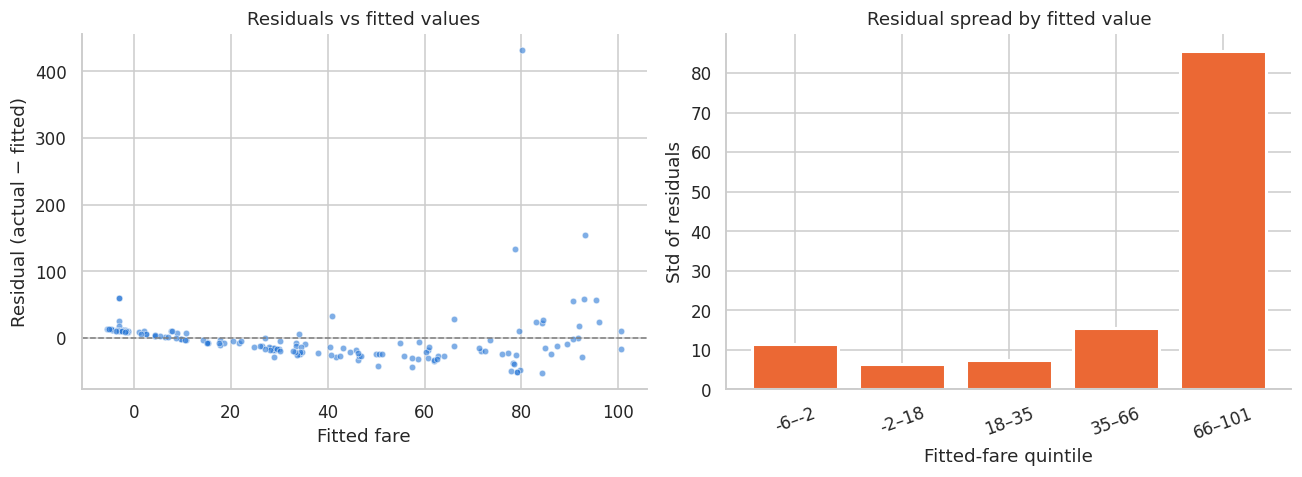

residual std per fitted-value quintile:
 (-5.527, -2.15]      11.44
(-2.15, 17.672]       6.36
(17.672, 34.517]      7.40
(34.517, 66.072]     15.49
(66.072, 100.551]    85.62
dtype: float64


In [16]:
resid = yr_test - pred_r
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(pred_r, resid, s=18, alpha=.6, color=COLOR_SURVIVED, edgecolor="white", linewidth=.5)
axes[0].axhline(0, color="grey", ls="--", lw=1)
axes[0].set(xlabel="Fitted fare", ylabel="Residual (actual − fitted)", title="Residuals vs fitted values")
bins = pd.qcut(pred_r, 5, duplicates="drop")
spread = pd.Series(resid.values).groupby(bins, observed=True).std()
axes[1].bar(range(len(spread)), spread.values, color=COLOR_DIED, edgecolor="white", linewidth=2)
axes[1].set_xticks(range(len(spread)), [f"{iv.left:.0f}–{iv.right:.0f}" for iv in spread.index], rotation=20)
axes[1].set(xlabel="Fitted-fare quintile", ylabel="Std of residuals", title="Residual spread by fitted value")
fig.tight_layout(); fig.savefig(FIG / "12_regression_residuals.png", bbox_inches="tight"); plt.show()
print("residual std per fitted-value quintile:\n", spread.round(2))

**Regression: predicting `fare`** from `pclass, age, sibsp, parch, survived, sex, embarked` (9 predictors after encoding; random 80/20 split; same train-only preprocessing pattern).

| MAE | RMSE | R² | Adjusted R² |
|---|---|---|---|
| 21.10 | 41.70 | 0.3482 | 0.3132 |

The model explains about **35% of the variance in fare** (31% after adjusting for 9 predictors on 178 test rows). The largest coefficient is `pclass` (−26.7 per SD). Family size (`parch` +8.9, `sibsp` +7.3) comes next, because a family ticket's fare covers everyone on it, and then Cherbourg embarkation (+9.7). RMSE is about double MAE, so the error is dominated by a few very large misses (the luxury fares).

**Heteroscedasticity: yes, clearly present.** The residuals do not form an even band around zero; they **fan out as the fitted value grows**. The residual standard deviation is about 6–15 for fitted fares below 66, but jumps to **85.6** in the top quintile (66–101), where the 1st-class luxury tickets sit, including one residual above +400. The low end also shows a systematic pattern: fitted values go *negative* (as low as −5.5) for cheap 3rd-class fares, where the residuals are all positive. That is a sign that a linear model on raw fare is mis-specified. A log-transformed target (`log1p(fare)`) or a tree-based regressor would be the natural fix. I kept the plain multivariate linear regression because the task asks for it.

## Task 14 — Final model comparison table

In [17]:
clf_table = results[["accuracy", "precision", "recall", "f1", "roc_auc"]]
clf_table.columns = pd.MultiIndex.from_product([["Classification metrics (test set, target = survived)"],
                                                ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]])
reg_table = pd.DataFrame([reg_metrics.values], index=["Linear Regression (fare)"],
                         columns=pd.MultiIndex.from_product([["Regression metrics (test set, target = fare)"],
                                                             ["MAE", "RMSE", "R²", "Adjusted R²"]]))
comparison = pd.concat([clf_table, reg_table]).round(4)
comparison.to_csv("model_comparison.csv")
comparison.fillna("—")

Classification metrics (test set, target = survived)                                    \
                                                                     Accuracy Precision  Recall      F1 ROC-AUC   
Logistic Regression                                                  0.8146      0.7966  0.6912  0.7402   0.861   
Decision Tree                                                        0.7978      0.7759  0.6618  0.7143   0.851   
Random Forest                                                        0.8146      0.7778  0.7206  0.7481  0.8283   
Random Forest (tuned)                                                0.8258      0.8033  0.7206  0.7597  0.8388   
Linear Regression (fare)                                                  —           —       —       —       —   

                         Regression metrics (test set, target = fare)                               
                                                                  MAE     RMSE      R² Adjusted R²  
Logistic Regression                                                 —        —       —           —  
Decision Tree                                                       —        —       —           —  
Random Forest                                                       —        —       —           —  
Random Forest (tuned)                                               —        —       —           —  
Linear Regression (fare)                                      21.0998  41.7022  0.3482      0.3132

### Final model comparison

| Model | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---|---|---|---|---|
| Logistic Regression | 0.8146 | 0.7966 | 0.6912 | 0.7402 | **0.8610** |
| Decision Tree (depth 4) | 0.7978 | 0.7759 | 0.6618 | 0.7143 | 0.8510 |
| Random Forest (default) | 0.8146 | 0.7778 | 0.7206 | 0.7481 | 0.8283 |
| **Random Forest (tuned)** | **0.8258** | **0.8033** | **0.7206** | **0.7597** | 0.8388 |

| Regression model (target = `fare`) | MAE | RMSE | R² | Adjusted R² |
|---|---|---|---|---|
| Linear Regression | 21.0998 | 41.7022 | 0.3482 | 0.3132 |

*The two groups are on different scales and are not comparable. Classification metrics are proportions in [0, 1] (higher is better). MAE/RMSE are in fare units (lower is better), and R²/Adj. R² are shares of fare variance explained. The notebook table keeps them as two separate column groups for the same reason.*

**Recommendation.** I would deploy the **tuned Random Forest** (`max_depth=8, max_features=None, n_estimators=100`). On the held-out test set it has the best accuracy (**0.8258**), precision (**0.8033**) and F1 (**0.7597**), and it ties for the best recall (**0.7206**). Its OOB accuracy of **0.8270** matches its test accuracy, so the gain over the default forest is not a lucky split. Logistic Regression is a close runner-up: it has the best ranking quality (AUC **0.8610** vs 0.8388) and is fully interpretable. I would pick it instead if the use case needed calibrated probabilities or explainable coefficients rather than the best hard yes/no decisions. The depth-4 Decision Tree is useful as the explanatory diagram above but trails on every metric (F1 0.7143), so it is not a deployment candidate.

## Task 15 — Save the complete fitted pipeline and prove it works on raw data

In [18]:
DEPLOY_NAME = "Random Forest (tuned)"
full_pipeline = models[DEPLOY_NAME]                       # ColumnTransformer (imputer+encoder+scaler) + estimator
joblib.dump(full_pipeline, "titanic_best_pipeline.joblib")
print("saved:", DEPLOY_NAME, "->", "titanic_best_pipeline.joblib",
      f"({Path('titanic_best_pipeline.joblib').stat().st_size / 1024:.0f} KB)")
print(full_pipeline)

saved: Random Forest (tuned) -> titanic_best_pipeline.joblib (970 KB)
Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['pclass', 'age', 'sibsp',
                                                   'parch', 'fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                      

In [19]:
reloaded = joblib.load("titanic_best_pipeline.joblib")

# 1) Identical predictions on the untouched raw test rows
assert (reloaded.predict(X_test) == full_pipeline.predict(X_test)).all()
print("reloaded test accuracy:", round(accuracy_score(y_test, reloaded.predict(X_test)), 4))

# 2) Brand-new raw passengers: raw strings, raw fares, and a missing age (NaN) — no manual preprocessing
new_passengers = pd.DataFrame([
    {"pclass": 1, "age": 29,     "sibsp": 0, "parch": 0, "fare": 211.34, "sex": "female", "embarked": "S"},
    {"pclass": 3, "age": 24,     "sibsp": 0, "parch": 0, "fare": 7.25,   "sex": "male",   "embarked": "S"},
    {"pclass": 2, "age": np.nan, "sibsp": 1, "parch": 2, "fare": 26.00,  "sex": "female", "embarked": "C"},
    {"pclass": 3, "age": 4,      "sibsp": 4, "parch": 2, "fare": 31.28,  "sex": "male",   "embarked": "S"},
])
new_passengers.assign(pred_survived=reloaded.predict(new_passengers),
                      p_survive=reloaded.predict_proba(new_passengers)[:, 1].round(3))

reloaded test accuracy: 0.8258


,pclass,age,sibsp,parch,fare,sex,embarked,pred_survived,p_survive
0,1,29.0,0,0,211.34,female,S,1,0.980
1,3,24.0,0,0,7.25,male,S,0,0.095
2,2,NaN,1,2,26.00,female,C,1,0.814
3,3,4.0,4,2,31.28,male,S,0,0.101


**Saved artifact.** `titanic_best_pipeline.joblib` is the **complete fitted `Pipeline`**: the `ColumnTransformer` (median imputer + `StandardScaler` for numeric features, most-frequent imputer + `OneHotEncoder` for `sex`/`embarked`) plus the tuned `RandomForestClassifier`. It is not a bare estimator. After `joblib.load`, it (1) reproduces the in-memory predictions on the test set exactly (asserted), with the same 0.8258 accuracy, and (2) scores brand-new **raw** passengers directly from strings, raw fares, and even a missing age (`NaN`, filled by the stored training median). A 1st-class woman gets p(survive) = 0.98 and a 3rd-class man 0.10. Those outputs are consistent with everything the EDA showed.

To use it elsewhere:
```python
import joblib, pandas as pd
model = joblib.load("titanic_best_pipeline.joblib")
model.predict(pd.DataFrame([{"pclass": 2, "age": 30, "sibsp": 0, "parch": 0, "fare": 13.0, "sex": "female", "embarked": "S"}]))
```